TASK 1: Univariate Analysis (Numerical Columns)

Understand distribution,

Detect skewness,

Identify need for transformation.


--- Unnamed: 0 ---
Mean: 11742.5
Median: 11742.5
Skewness: 0.0
Kurtosis: -1.2000000000000002


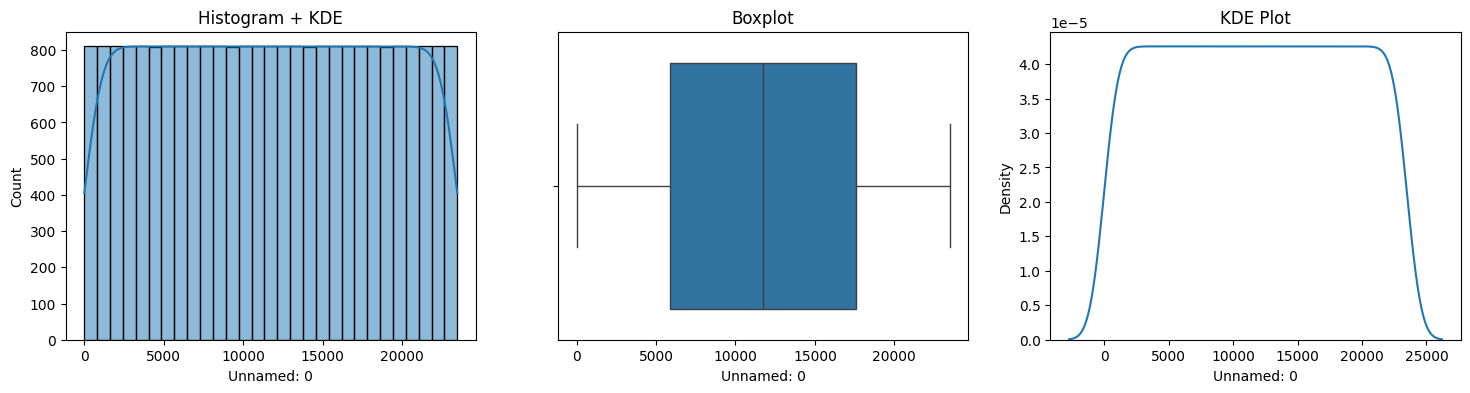


--- Clothing ID ---
Mean: 918.1187090181385
Median: 936.0
Skewness: -2.0876360043920954
Kurtosis: 5.182270319133702


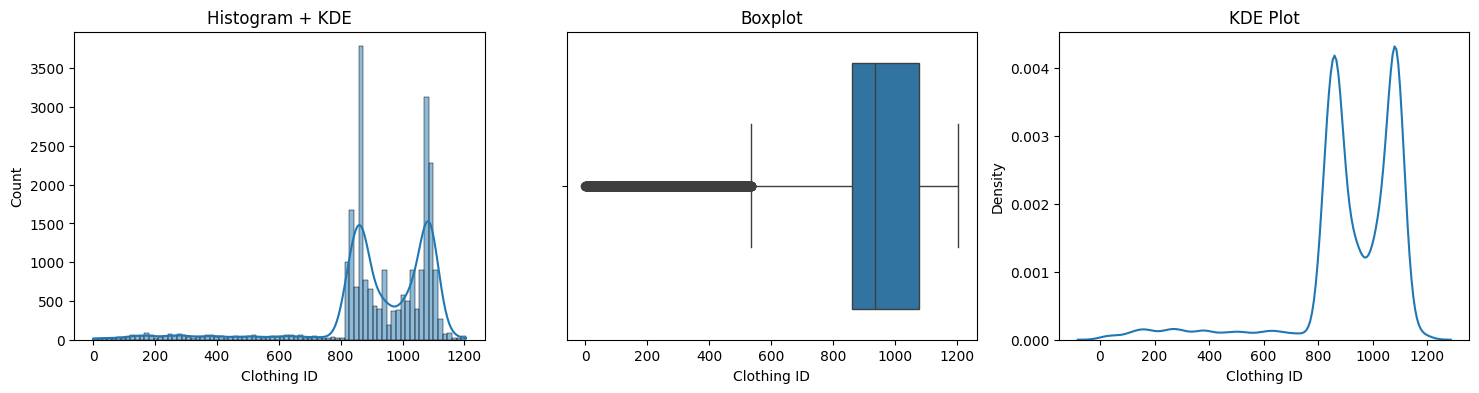


--- Age ---
Mean: 43.198543813335604
Median: 41.0
Skewness: 0.5256145063517778
Kurtosis: -0.11182071373186542


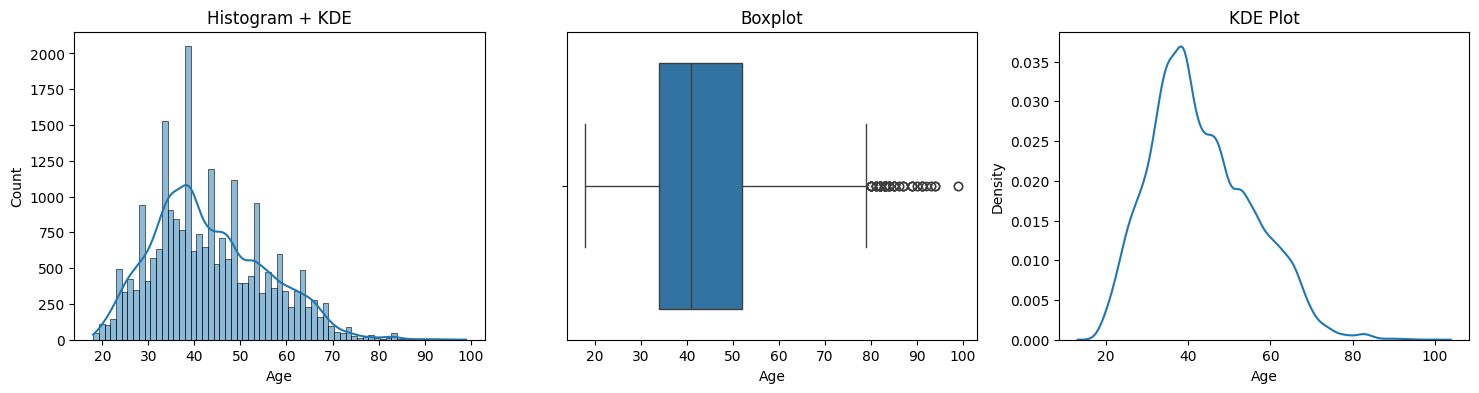


--- Rating ---
Mean: 4.196031678446734
Median: 5.0
Skewness: -1.3135291052307205
Kurtosis: 0.8041359316696282


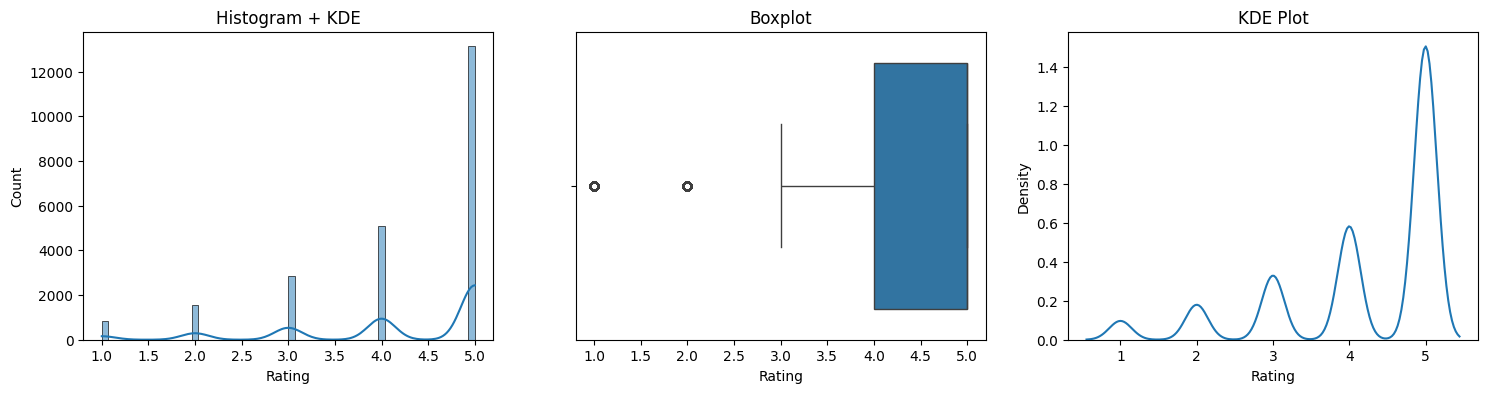


--- Recommended IND ---
Mean: 0.8223622583666865
Median: 1.0
Skewness: -1.6869519680564828
Kurtosis: 0.8458789678902989


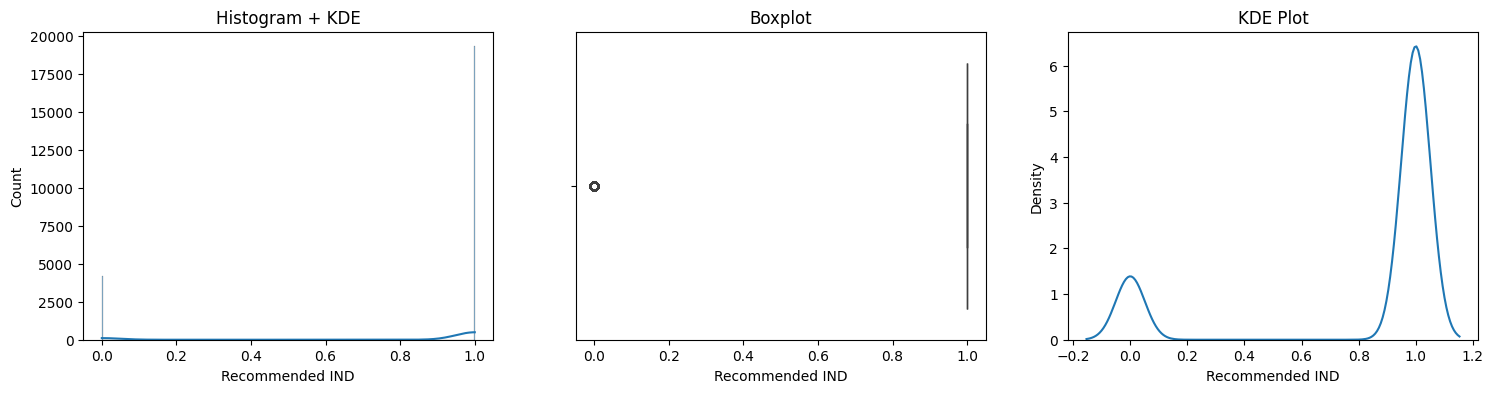


--- Positive Feedback Count ---
Mean: 2.535936302478072
Median: 1.0
Skewness: 6.47299772950122
Kurtosis: 71.6931786799819


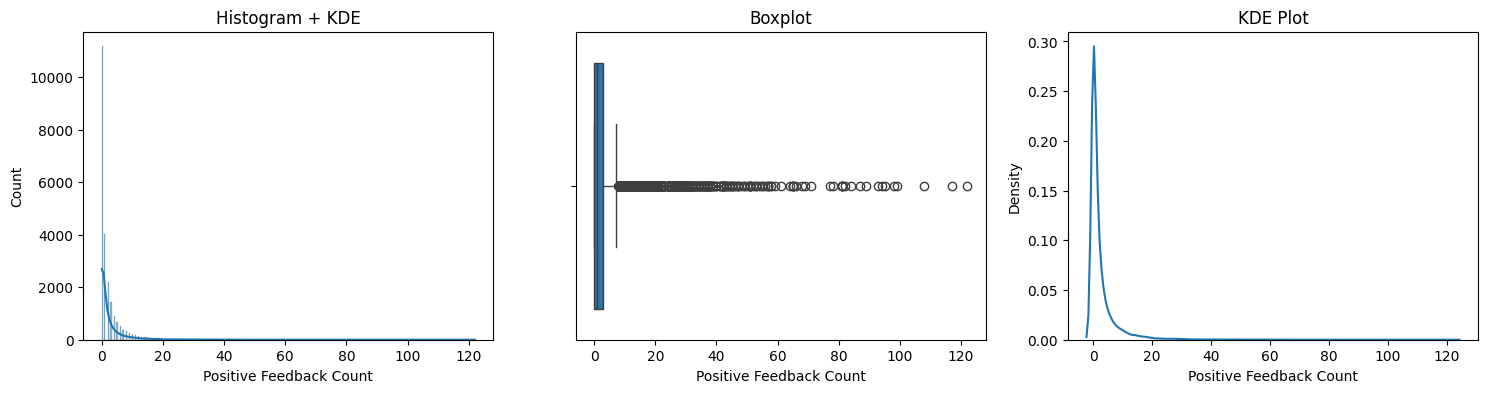

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# df = pd.read_csv("data/womens_clothing_reviews.csv")
df = pd.read_csv("../data/womens_clothing_reviews.csv")

num_cols = df.select_dtypes(include=np.number).columns

def analyze_numerical(df, col):
    print(f"\n--- {col} ---")
    
    # Stats
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Skewness:", df[col].skew())
    print("Kurtosis:", df[col].kurt())

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title("Histogram + KDE")

    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title("Boxplot")

    sns.kdeplot(df[col], ax=axes[2])
    axes[2].set_title("KDE Plot")

    plt.show()


for col in num_cols:
    analyze_numerical(df, col)

TASK 2: Categorical Analysis

Frequency distribution,

Handle high-cardinality,

Entropy importance.


--- Title ---
Title
Love it!      136
Beautiful      95
Love           88
Love!          84
Beautiful!     72
Name: count, dtype: int64
Entropy: 9.093153732259937


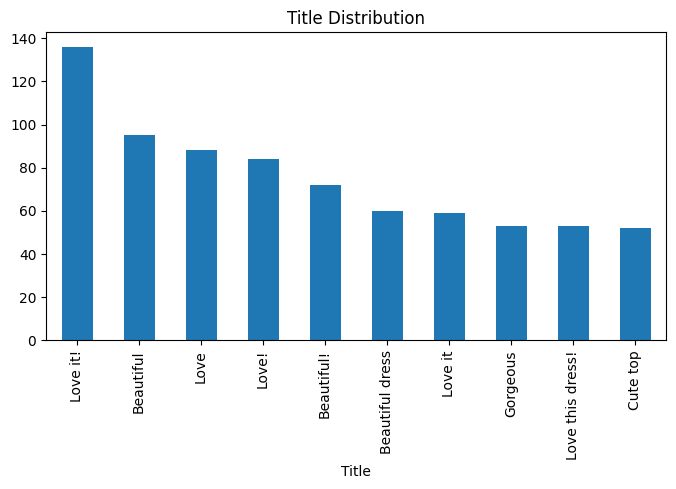


--- Review Text ---
Review Text
Perfect fit and i've gotten so many compliments. i buy all my suits from here now!                                                                                                                                                                                                                                                                                                                                                                                                                                        3
Lightweight, soft cotton top and shorts. i think it's meant to be a beach cover-up but i'm wearing it as a thin, light-weight summer outfit on these hot hot days. the top has a loose elastic around the bottom which i didn't realize when i ordered it, but i like it and it matches the look in the photos. and the shorts are very low-cut - don't expect them up around your waist. again, i like that. some might want to wear a cami underneath because it's a thin

) missing from font(s) DejaVu Sans.iny beam\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 13 (
  fig.canvas.print_figure(bytes_io, **kw)


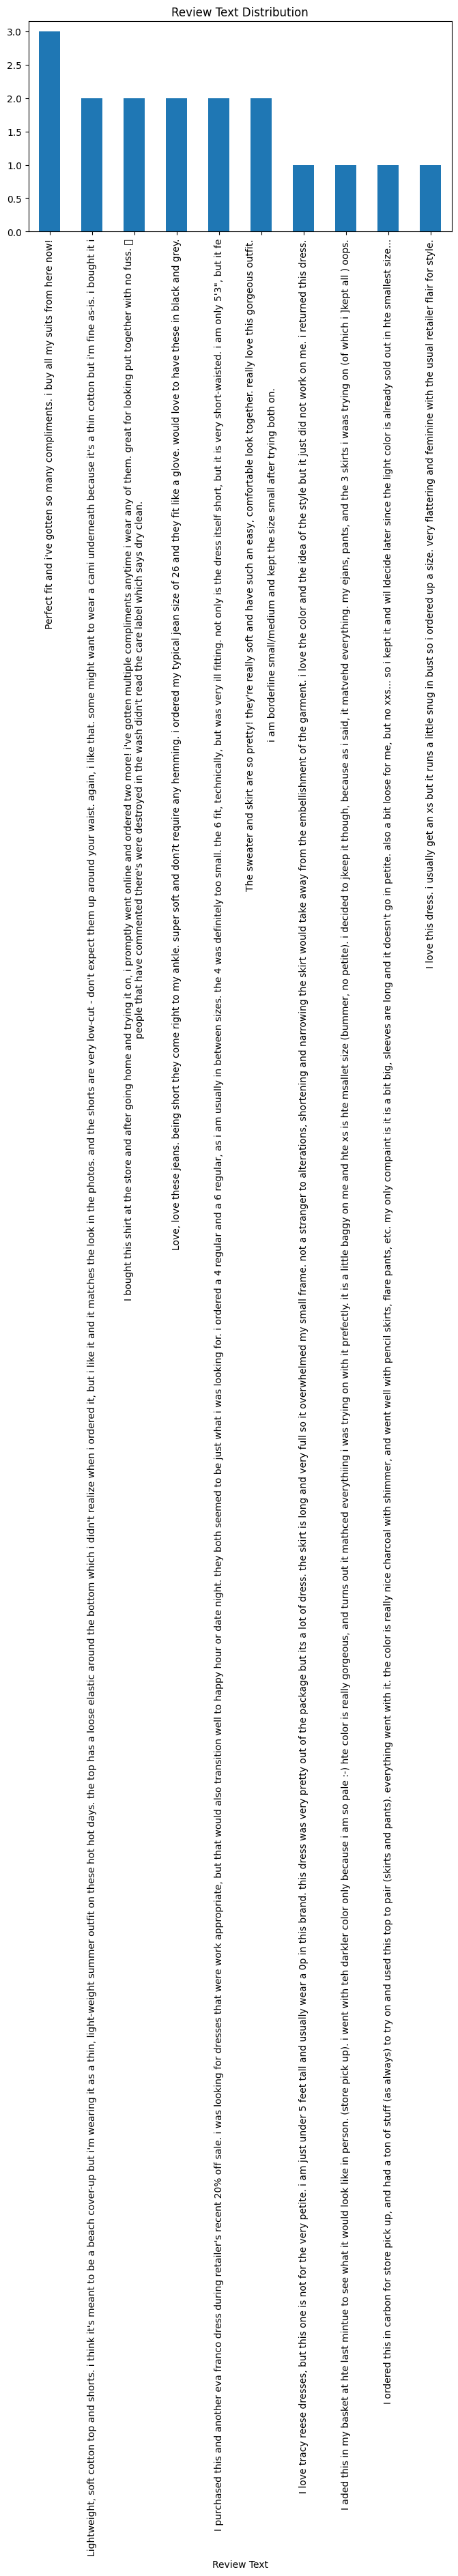


--- Division Name ---
Division Name
General           13850
General Petite     8120
Initmates          1502
Name: count, dtype: int64
Entropy: 0.8543971252443127


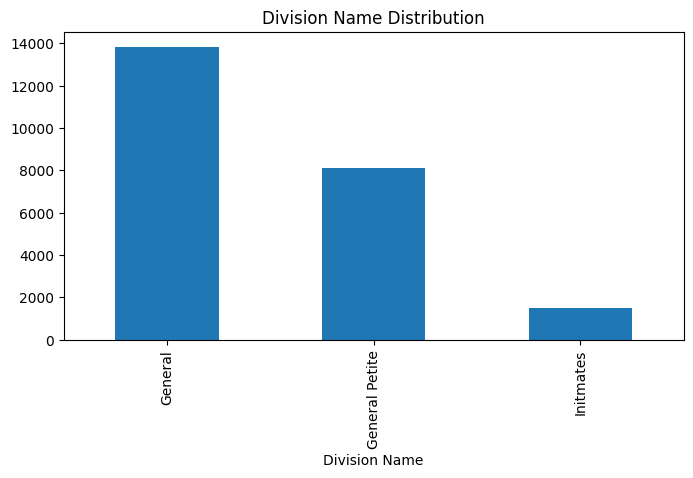


--- Department Name ---
Department Name
Tops        10468
Dresses      6319
Bottoms      3799
Intimate     1735
Jackets      1032
Name: count, dtype: int64
Entropy: 1.364841399348087


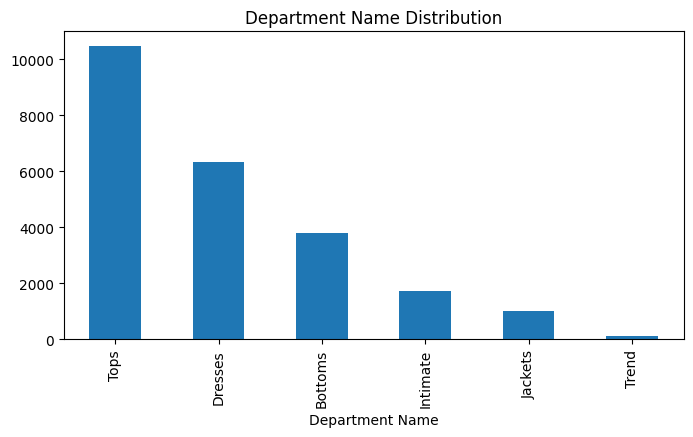


--- Class Name ---
Class Name
Dresses     6319
Knits       4843
Blouses     3097
Sweaters    1428
Pants       1388
Name: count, dtype: int64
Entropy: 2.2659333917713402


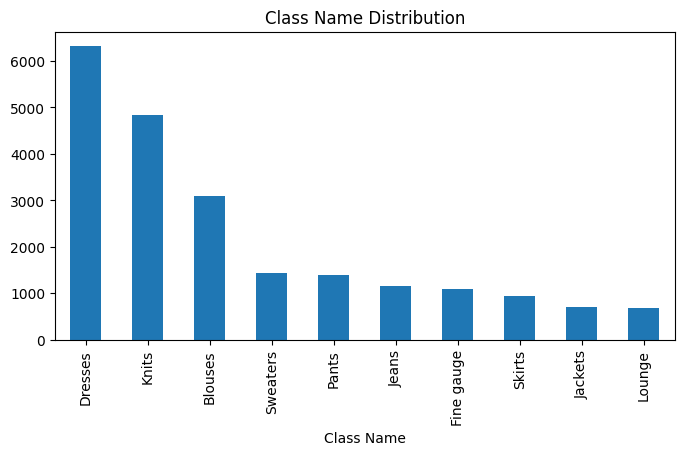

In [3]:
cat_cols = df.select_dtypes(include='object').columns

from scipy.stats import entropy

def analyze_categorical(df, col):
    print(f"\n--- {col} ---")

    freq = df[col].value_counts()
    print(freq.head())

    # Entropy
    ent = entropy(freq)
    print("Entropy:", ent)

    # Bar plot
    freq.head(10).plot(kind='bar', figsize=(8,4))
    plt.title(f"{col} Distribution")
    plt.show()

for col in cat_cols:
    analyze_categorical(df, col)

TASK 3: Ratings Distribution + Gaussian Mixture Model

Find hidden patterns

Segment users

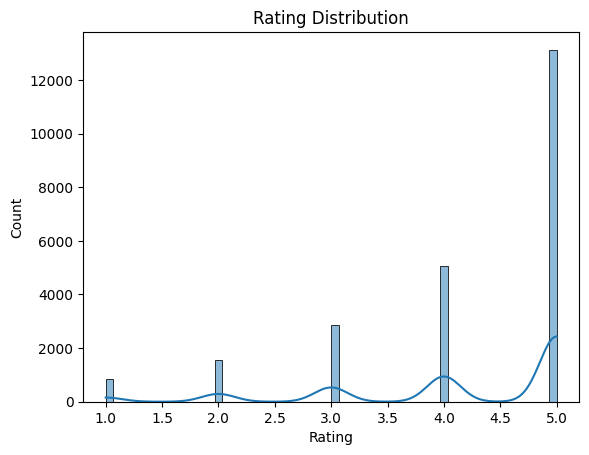

In [4]:
from sklearn.mixture import GaussianMixture

rating_col = "Rating"  # adjust if needed

data = df[[rating_col]].dropna()

gmm = GaussianMixture(n_components=3)
gmm.fit(data)

labels = gmm.predict(data)

df["rating_cluster"] = np.nan
df.loc[data.index, "rating_cluster"] = labels

sns.histplot(df[rating_col], kde=True)
plt.title("Rating Distribution")
plt.show()

TASK 4: Correlation Analysis (Advanced)

Pearson

Spearman

Kendall

Heatmap

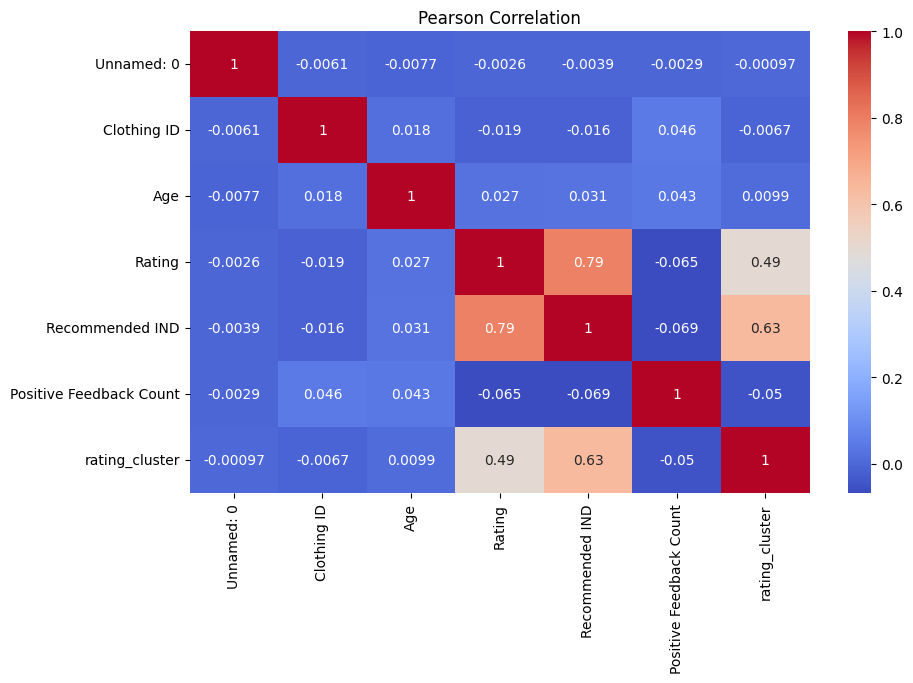

In [5]:
num_df = df.select_dtypes(include=np.number)

pearson = num_df.corr(method='pearson')
spearman = num_df.corr(method='spearman')
kendall = num_df.corr(method='kendall')

plt.figure(figsize=(10,6))
sns.heatmap(pearson, annot=True, cmap="coolwarm")
plt.title("Pearson Correlation")
plt.show()

TASK 5: Summary Report Generator (NLP Style)

Auto insights

Human-readable summary

In [6]:
def generate_summary(df):
    report = []

    for col in df.select_dtypes(include=np.number).columns:
        mean = df[col].mean()
        skew = df[col].skew()

        if skew > 1:
            trend = "Highly right skewed"
        elif skew < -1:
            trend = "Highly left skewed"
        else:
            trend = "Approximately normal"

        report.append(f"{col}: mean={mean:.2f}, {trend}")

    return report


summary = generate_summary(df)

for line in summary:
    print(line)

Unnamed: 0: mean=11742.50, Approximately normal
Clothing ID: mean=918.12, Highly left skewed
Age: mean=43.20, Approximately normal
Rating: mean=4.20, Highly left skewed
Recommended IND: mean=0.82, Highly left skewed
Positive Feedback Count: mean=2.54, Highly right skewed
rating_cluster: mean=0.99, Approximately normal
